In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
df = pd.read_csv('../results/results_all_combos.csv')
df[['team-1 strategy','team-2 strategy']] = df[['team-2 strategy','team-1 strategy']]
print(df.columns)

Index(['game num', 'round num', 'num_turns', 'duration (ms)', 'winner',
       'team-1 strategy', 'team-2 strategy', 'player1 pts', 'player2 pts',
       'player3 pts', 'player4 pts', 'started on set', 'went out first',
       'personal points scored ig', 'personal points scored eog'],
      dtype='object')


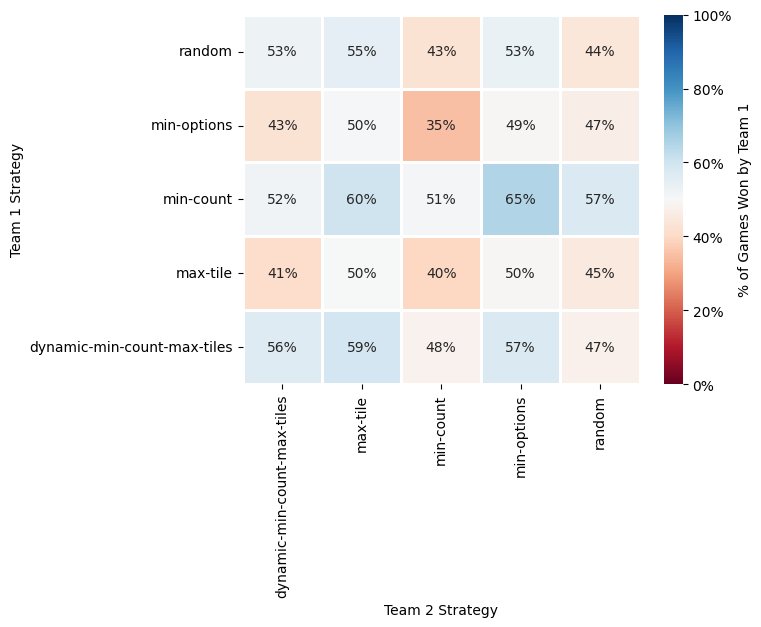

In [4]:
#grouped = df.groupby('game num')

lastrounds = df.groupby(['team-1 strategy','team-2 strategy','game num']).last().reset_index()
lastrounds['team odd pts'] = lastrounds['player1 pts'] + lastrounds['player3 pts']
lastrounds['team even pts'] = lastrounds['player2 pts'] + lastrounds['player4 pts']
lastrounds['odd wins'] = (lastrounds['team odd pts'] > lastrounds['team even pts'])
combo_wins = lastrounds.groupby(['team-1 strategy','team-2 strategy'])['odd wins'].sum().reset_index()#.transform()#.agg({'odd wins','sum'})
combo_wins['odd win pct'] = (combo_wins['odd wins'] / 500)
piv = combo_wins.pivot(index='team-1 strategy', columns='team-2 strategy', values='odd win pct')
piv = piv.fillna(1-piv.T)
#piv = piv[piv.columns[::-1]]
piv = piv[::-1]
ax = sns.heatmap(piv, cmap='RdBu', center=0.5, annot=True, fmt='.0%', vmin=0, vmax=1, linewidths=1, 
                 cbar_kws={'label': '% of Games Won by Team 1'})#,# 'format': '%.0%%'})
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Team 2 Strategy')
ax.set_ylabel('Team 1 Strategy')
plt.show()


In [5]:
lastrounds = df.groupby(['team-1 strategy','team-2 strategy','game num']).last().reset_index()
lastrounds['team odd pts'] = lastrounds['player1 pts'] + lastrounds['player3 pts']
lastrounds['team even pts'] = lastrounds['player2 pts'] + lastrounds['player4 pts']
lastrounds['odd wins'] = (lastrounds['team odd pts'] > lastrounds['team even pts'])
combo_wins = lastrounds.groupby(['team-1 strategy','team-2 strategy'])['odd wins'].sum().reset_index()#.transform()#.agg({'odd wins','sum'})
combo_wins['odd win pct'] = (combo_wins['odd wins'] / 500)
piv = combo_wins.pivot(index='team-1 strategy', columns='team-2 strategy', values='odd win pct')

In [6]:
df = df.rename(columns={'personal points scored ig': 'ppsig', 'personal points scored eog': 'ppseog'})
df['score_ratio'] = df['ppseog']#df['ppseog']# / df['ppsig']
df = df[df['winner'] != 'none']
grouped = df.groupby(['team-1 strategy','team-2 strategy'])
grouped['score_ratio'].mean()

team-1 strategy              team-2 strategy            
dynamic-min-count-max-tiles  dynamic-min-count-max-tiles    2.755861
                             max-tile                       2.670673
                             min-count                      3.041051
                             min-options                    2.641429
max-tile                     max-tile                       2.351412
                             min-count                      2.686064
                             min-options                    2.353106
min-count                    min-count                      3.189189
min-options                  min-count                      2.735091
                             min-options                    2.310461
random                       dynamic-min-count-max-tiles    2.550350
                             max-tile                       2.417039
                             min-count                      2.889399
                             min-options      

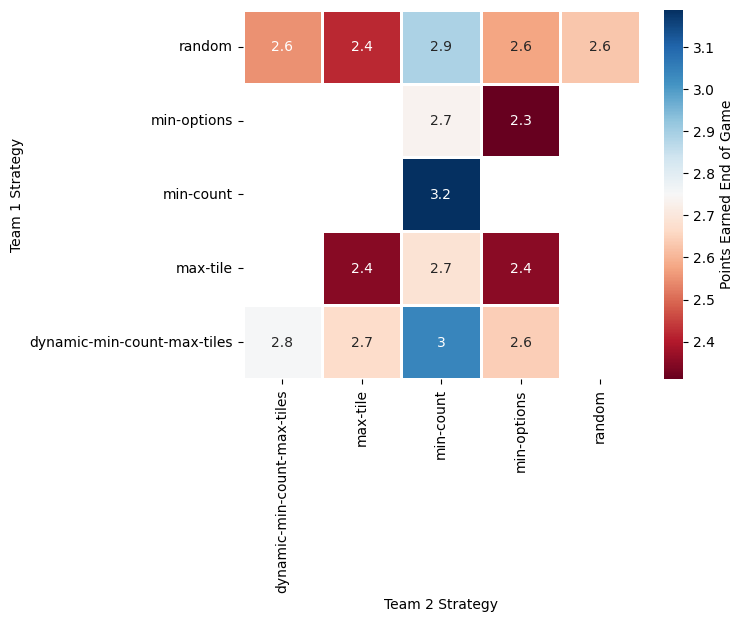

In [7]:
df_clean = df[np.isfinite(df['score_ratio'])]
grouped = df_clean.groupby(['team-1 strategy','team-2 strategy'])
ratios = grouped['score_ratio'].mean().reset_index()
piv = ratios.pivot(index='team-1 strategy', columns='team-2 strategy', values='score_ratio')
#piv = piv.fillna(1-piv.T)
#piv = piv[piv.columns[::-1]]
piv = piv[::-1]

ax = sns.heatmap(piv, cmap='RdBu', annot=True, linewidths=1, 
                 cbar_kws={'label': 'Points Earned End of Game'})
cbar = ax.collections[0].colorbar
# cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Team 2 Strategy')
ax.set_ylabel('Team 1 Strategy')
plt.show()

In [8]:
df['score_ratio'] = df['ppsig']#df['ppseog']# / df['ppsig']
df = df[df['winner'] != 'none']
grouped = df.groupby(['team-1 strategy','team-2 strategy'])
grouped['score_ratio'].mean()

team-1 strategy              team-2 strategy            
dynamic-min-count-max-tiles  dynamic-min-count-max-tiles    3.481579
                             max-tile                       3.576502
                             min-count                      3.213793
                             min-options                    3.688036
max-tile                     max-tile                       3.849074
                             min-count                      3.385231
                             min-options                    3.903376
min-count                    min-count                      3.048617
min-options                  min-count                      3.485867
                             min-options                    4.012866
random                       dynamic-min-count-max-tiles    3.780155
                             max-tile                       3.866629
                             min-count                      3.391016
                             min-options      

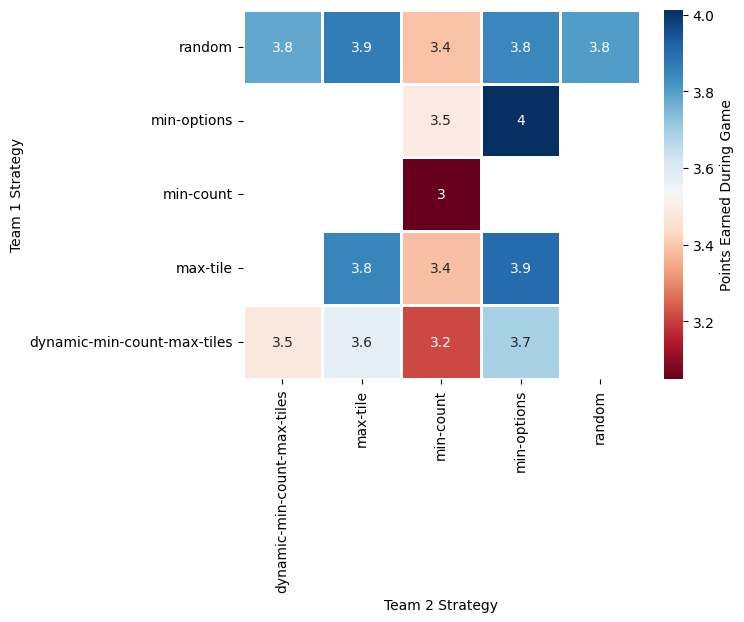

In [9]:
df_clean = df[np.isfinite(df['score_ratio'])]
grouped = df_clean.groupby(['team-1 strategy','team-2 strategy'])
ratios = grouped['score_ratio'].mean().reset_index()
piv = ratios.pivot(index='team-1 strategy', columns='team-2 strategy', values='score_ratio')
#piv = piv.fillna(1-piv.T)
#piv = piv[piv.columns[::-1]]
piv = piv[::-1]

ax = sns.heatmap(piv, cmap='RdBu', annot=True, linewidths=1, 
                 cbar_kws={'label': 'Points Earned During Game'})
cbar = ax.collections[0].colorbar
# cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Team 2 Strategy')
ax.set_ylabel('Team 1 Strategy')
plt.show()